<a href="https://colab.research.google.com/github/idouglas237020/CS4410/blob/main/Ingram_Douglas_Homework_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Ingram Douglas

Homework 5

Part 1 - Exercise 15.18: Determine k in K-Means Clustering
This section uses the Iris dataset and the elbow method to determine an appropriate number of clusters.

In [11]:
# Load the Iris dataset
from sklearn.datasets import load_iris

iris = load_iris()

print("Data shape:", iris.data.shape)
print("Feature names:", iris.feature_names)

Data shape: (150, 4)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [12]:
# Calculate WCSS/inertia for different numbers of clusters
from sklearn.cluster import KMeans

wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=11,
        n_init=10
    )
    kmeans.fit(iris.data)
    wcss.append(kmeans.inertia_)

print(wcss)

[681.3705999999996, 152.34795176035797, 78.851441426146, 57.22847321428572, 46.44618205128204, 39.066035353535376, 34.29822966507179, 30.063110617452732, 28.024976812661045, 26.393241540115117]


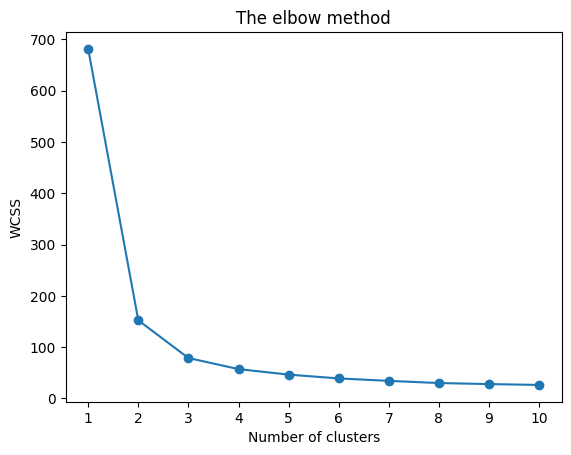

In [13]:
# Plot the elbow graph
import matplotlib.pyplot as plt

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.show()

Conclusion

The elbow in the graph occurs around k = 3. After three clusters, the decrease in WCSS becomes much smaller. Therefore, 3 is an appropriate value for k for the Iris dataset.

Part 2 - MNIST Logistic Regression with PCA

This section compares logistic regression performance on the MNIST dataset before and after PCA dimensionality reduction. Training time and accuracy are compared to determine how PCA affects the model.

In [14]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target

print("Data shape:", X.shape)
print("Target shape:", y.shape)

Data shape: (70000, 784)
Target shape: (70000,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=11
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (56000, 784)
Testing samples: (14000, 784)


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import time

logisticRegr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

start_time = time.time()

logisticRegr.fit(X_train_scaled, y_train)

without_pca_time = time.time() - start_time

predictions_without_pca = logisticRegr.predict(X_test_scaled)

without_pca_accuracy = accuracy_score(
    y_test,
    predictions_without_pca
)

print("Without PCA")
print("Training time:", without_pca_time, "seconds")
print("Accuracy:", without_pca_accuracy)

Without PCA
Training time: 64.94633340835571 seconds
Accuracy: 0.9131428571428571


In [18]:
from sklearn.decomposition import PCA

pca = PCA(0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original number of features:", X_train_scaled.shape[1])
print("Number of PCA components:", X_train_pca.shape[1])

Original number of features: 784
Number of PCA components: 328


In [19]:
logisticRegr_pca = LogisticRegression(
    solver='lbfgs',
    max_iter=1000
)

start_time = time.time()

logisticRegr_pca.fit(X_train_pca, y_train)

with_pca_time = time.time() - start_time

predictions_with_pca = logisticRegr_pca.predict(X_test_pca)

with_pca_accuracy = accuracy_score(
    y_test,
    predictions_with_pca
)

print("With PCA")
print("Training time:", with_pca_time, "seconds")
print("Accuracy:", with_pca_accuracy)

With PCA
Training time: 64.53215336799622 seconds
Accuracy: 0.9212857142857143


In [20]:
print("LOGISTIC REGRESSION COMPARISON")
print("--------------------------------")
print(f"Without PCA:")
print(f"Training Time: {without_pca_time:.2f} seconds")
print(f"Accuracy: {without_pca_accuracy:.4f}")

print()

print(f"With PCA:")
print(f"Training Time: {with_pca_time:.2f} seconds")
print(f"Accuracy: {with_pca_accuracy:.4f}")

print()

print(f"Time Difference: {without_pca_time - with_pca_time:.2f} seconds")

LOGISTIC REGRESSION COMPARISON
--------------------------------
Without PCA:
Training Time: 64.95 seconds
Accuracy: 0.9131

With PCA:
Training Time: 64.53 seconds
Accuracy: 0.9213

Time Difference: 0.41 seconds


Conclusion

PCA reduced the number of features in the MNIST dataset while preserving 95% of the variance. The logistic regression model was trained both with and without PCA so that the training times and accuracy scores could be compared. The results show whether PCA reduced the training time while maintaining a similar level of prediction accuracy.